In [14]:
from google.colab import drive

# mounting my google drive
drive.mount("/content/gdrive", force_remount=True)

pic_root = "/content/gdrive/MyDrive/Astronomie/Astrophoto/Moon/060325/"

import os

# ! ls $pic_root
print(os.path.exists(pic_root))
print(os.listdir(pic_root))

# Clone the repo "Handheld Multi-Frame Super-Resolution"
! git clone https://github.com/mfournigault/Handheld-Multi-Frame-Super-Resolution.git





Mounted at /content/gdrive
True
['P1040213.dng', 'P1040227.dng', 'P1040224.dng', 'P1040222.dng', 'P1040228.dng', 'P1040218.dng', 'P1040215.dng', 'P1040221.dng', 'P1040226.dng', 'P1040219.dng', 'P1040223.dng', 'P1040225.dng', 'P1040214.dng', 'P1040220.dng', 'P1040217.dng', 'P1040216.dng', 'moon_060325_super_resolution.png', 'super_resolution']
fatal: destination path 'Handheld-Multi-Frame-Super-Resolution' already exists and is not an empty directory.


In [15]:
print(os.getcwd())

/content


In [16]:
# !uv pip install -q --system numba-cuda==0.4.0

In [17]:
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

In [18]:
import os

mfsr_root = "/content/Handheld-Multi-Frame-Super-Resolution"
venv_path = "/content/gdrive/MyDrive/venvs/mf-superres"


In [19]:
# @title
import os

mfsr_root = "/content/Handheld-Multi-Frame-Super-Resolution"
venv_path = "/content/gdrive/MyDrive/venvs/mf-superres"

print(f"Creating virtual environment at {venv_path}...")
# Use virtualenv which works better on Google Drive than standard venv
# !pip install -q virtualenv
# !virtualenv {venv_path}

# print("Upgrading pip and installing build tools...")
# !{venv_path}/bin/python -m pip install --upgrade pip setuptools wheel

# # print("Fixing versions in requirements.txt for Python 3.12 compatibility...")
# # # Strict pin to numpy 1.26.4 to avoid ABI incompatibility with numpy 2.x
# # !sed -i 's/numpy==1.23.4/numpy==1.26.4/g' "{mfsr_root}/requirements.txt"
# # !sed -i 's/numpy>=1.26.0/numpy==1.26.4/g' "{mfsr_root}/requirements.txt"

# # !sed -i 's/rawpy==0.18/rawpy>=0.19.0/g' "{mfsr_root}/requirements.txt"
# # !sed -i 's/torch==1.13.1/torch>=2.2.0/g' "{mfsr_root}/requirements.txt"
# # !sed -i 's/scipy==1.10.0/scipy>=1.12.0/g' "{mfsr_root}/requirements.txt"
# # !sed -i 's/colour-demosaicing==0.2.3/colour-demosaicing>=0.2.5/g' "{mfsr_root}/requirements.txt"
# # !sed -i 's/scikit-image==0.19.3/scikit-image>=0.22.0/g' "{mfsr_root}/requirements.txt"

# print("Installing requirements into the virtual environment...")
# # Use the venv's python executable directly to install packages with the absolute path to requirements.txt
# !{venv_path}/bin/python -m pip install -r "{mfsr_root}/requirements.txt"

Creating virtual environment at /content/gdrive/MyDrive/venvs/mf-superres...


When the env is created in your G-drive, with the packages installed inside it, you can comment the code above (for installing requirements), and just import the path to your env packages to use them as below.

We prepare the context of execution of the super_resolution algorithm with options, parameters etc...

In [20]:
from omegaconf import OmegaConf

# Load the default configuration
default_conf = OmegaConf.load("/content/Handheld-Multi-Frame-Super-Resolution/configs/default.yaml")


In [21]:
import sys
import os
import glob
import shutil

# Configuration des chemins apres un redemarrage
py_version = f"{sys.version_info.major}.{sys.version_info.minor}"
venv_site_packages = f"/content/gdrive/MyDrive/venvs/mf-superres/lib/python{py_version}/site-packages"
mfsr_root = "/content/Handheld-Multi-Frame-Super-Resolution"

if venv_site_packages not in sys.path:
    sys.path.insert(0, venv_site_packages)
if mfsr_root not in sys.path:
    sys.path.insert(0, mfsr_root)

In [80]:


import rawpy
from omegaconf import OmegaConf
from handheld_super_resolution import process

# Load the default configuration
default_conf = OmegaConf.load(os.path.join(mfsr_root, "configs/default.yaml"))
print(default_conf)

my_custom_conf = OmegaConf.create({
    "verbose": 2,
    "scale": 1,
    "debug": False,
    "merging" : {
        "kernel": "steerable"
    },
    "accumulated robustness denoiser" : {
        "merge": {
            "on": True,
            "rad max": 2,
            "max multiplier": 8,
            "max frame count": 16
        }
    },
    "post processing" : {
        "on": True,
        "do color correction": True,
        "do tonemapping": True,
        "do gamma": True,
        "do devignette": False,
        "do sharpening": True
    }
})

config = OmegaConf.merge(default_conf, my_custom_conf)

# --- DEBUG: Test sur 3 images et verification des dimensions ---
pic_root = "/content/gdrive/MyDrive/Astronomie/Astrophoto/Moon/060325/"
all_dngs = sorted(glob.glob(os.path.join(pic_root, "*.dng")))

print(f"Total images trouvees : {len(all_dngs)}")
if len(all_dngs) > 0:
    with rawpy.imread(all_dngs[0]) as raw:
        print("Shape de l'image RAW vue par rawpy :", raw.raw_image_visible.shape)

# test_dir = "/content/temp_test_dng"
# os.makedirs(test_dir, exist_ok=True)
# for f in glob.glob(os.path.join(test_dir, "*.dng")):
#     os.remove(f) # Nettoyage si dejà present

# # On copie seulement les 3 premieres images
# for f in all_dngs[:3]:
#     shutil.copy(f, test_dir)



{'scale': 1, 'mode': 'bayer', 'debug': False, 'verbose': 1, 'grey_method': 'FFT', 'noise_model': {'alpha': None, 'beta': None}, 'block_matching': {'tuning': {'factors': [1, 2, 4, 4], 'tile_size': 'SNR_based', 'tile_size_factors': [1, 1, 1, 0.5], 'search_radii': [1, 4, 4, 4], 'metrics': ['L1', 'L2', 'L2', 'L2'], 'flow_upscale_mode': 'nearest'}}, 'ica': {'tuning': {'n_iter': 3, 'sigma_blur': 0}}, 'robustness': {'enabled': True, 'save_mask': True, 'tuning': {'t': 0.12, 's1': 2, 's2': 12, 'Mt': 0.8}}, 'merging': {'kernel': 'steerable', 'selection_law': 'linear', 'tuning': {'k_detail': 'SNR_based', 'k_denoise': 'SNR_based', 'D_th': 'SNR_based', 'D_tr': 'SNR_based', 'k_stretch': 4, 'k_shrink': 2}}, 'postprocessing': {'enabled': True, 'do_color_correction': False, 'do_gamma_correction': True, 'do_tonemapping': False, 'sharpening': {'enabled': True, 'amount': 1.5, 'radius': 3}, 'do_devignetting': False}, 'accumulated_robustness_denoiser': {'median': {'enabled': False, 'radius_max': 3, 'max_fra

In [81]:
from handheld_super_resolution.utils_dng import load_dng_burst

burst_path = pic_root
ref_raw, raw_comp, ISO, tags, CFA, xyz2cam, white_balance, ref_path = load_dng_burst(burst_path)
print(white_balance)
print(CFA)

[2.1056621074676514, 1.0, 1.8339639902114868, 0.0]
[[1 2]
 [0 1]]


In [82]:
config.exif = OmegaConf.create({
    "cfa_pattern": CFA.tolist(),
    "iso": ISO,
    "white_balance": white_balance,
})

In [83]:
print(f"\nLancement du traitement sur {len(all_dngs)} images...")
output_img, debug_dict = process(pic_root, config)



Lancement du traitement sur 16 images...
Estimating noise curves ...


Brightnesses: 100%|██████████| 39/39 [00:00<00:00, 46.74it/s]


 -- Read raw files                                  :  10064.72 milliseconds
  ----------
|ISO : 160
|Image brightness : 0.01
|expected noise std : 1.25e-03
|Estimated SNR : 6.78

Processing reference image ---------


Initializing alignment
Alignment initialized (Total)                       :  24.43 milliseconds

Estimating ref image local stats
Local stats estimated (Total)                       :  135.74 milliseconds

Ref Img processed (Total)                          :  316.83 milliseconds

Processing image 1 ---------


Beginning alignment
Image aligned (Total)                               :  25.84 milliseconds

Estimating robustness
Robustness estimated (Total)                        :  68.34 milliseconds

Estimating kernels
Kernels estimated (Total)                           :  7.89 milliseconds

Accumulating Image
Image accumulated (Total)                           :  63.81 milliseconds

Image processed (Total)                            :  205.98 milliseconds

Processing ima

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Plotting intermediate results on alignment, robustness, etc ..
flow = np.array(debug_dict.get("flow", []))

if flow.ndim >= 3:
  print(flow.shape[1], flow.shape[2])

  # Calculate the number of rows and columns for the subplots
  num_frames = flow.shape[0]
  num_cols = 2  # Number of columns in the subplot grid
  num_rows = (num_frames + num_cols - 1) // num_cols  # Calculate number of rows needed

  # Create the figure and subplots with the calculated dimensions
  fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 20))
  fig.suptitle("Optical Flow alignement")
  fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.5)

  # Iterate through the frames and plot them in the corresponding subplots
  for i in range(num_frames):
    x, y = np.mgrid[0:flow.shape[1], 0:flow.shape[2]]

    # Calculate the row and column index for the current subplot
    row_index = i // num_cols
    col_index = i % num_cols

    # Access the subplot using the calculated indices
    ax = axs[row_index, col_index] if num_rows > 1 else axs[col_index]

    ax.set_title("Image alignment {}".format(i))
    ax.quiver(x, y, flow[i, :, :, 0], flow[i, :, :, 1])

  # Hide any unused subplots, if necessary
  for i in range(num_frames, num_rows * num_cols):
    row_index = i // num_cols
    col_index = i % num_cols
    ax = axs[row_index, col_index] if num_rows > 1 else axs[col_index]
    ax.set_visible(False)
else:
  print("Aucune donnée 'flow' disponible. Assurez-vous que 'debug': True est défini dans la configuration.")


Aucune donnée 'flow' disponible. Assurez-vous que 'debug': True est défini dans la configuration.


In [85]:
robustness = np.array(debug_dict.get("robustness", []))
print(robustness.shape)

if robustness.ndim >= 3 and robustness.shape[0] > 0:
  num_frames = robustness.shape[0]
  num_cols = 2  # Number of columns in the subplot grid
  num_rows = (num_frames + num_cols - 1) // num_cols  # Calculate number of rows needed

  # Create the figure and subplots with the calculated dimensions
  fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 20))
  fig.suptitle("Robustness")
  fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.5)

  for i in range(0, robustness.shape[0]):
    x,y = np.mgrid[0:robustness.shape[1], 0:robustness.shape[2]]

    # Calculate the row and column index for the current subplot
    row_index = i // num_cols
    col_index = i % num_cols

    # Access the subplot using the calculated indices
    ax = axs[row_index, col_index] if num_rows > 1 else axs[col_index]
    ax.set_title("Image Robustness {}".format(i))
    img = ax.imshow(robustness[i,:,:])
    fig.colorbar(img,ax=ax)

  # Hide any unused subplots, if necessary
  for i in range(num_frames, num_rows * num_cols):
    row_index = i // num_cols
    col_index = i % num_cols
    ax = axs[row_index, col_index] if num_rows > 1 else axs[col_index]
    ax.set_visible(False)

  plt.show()
else:
  print("Aucune donnée 'robustness' disponible. Assurez-vous que 'debug': True est défini dans la configuration.")


(0,)
Aucune donnée 'robustness' disponible. Assurez-vous que 'debug': True est défini dans la configuration.


(4016, 3016)


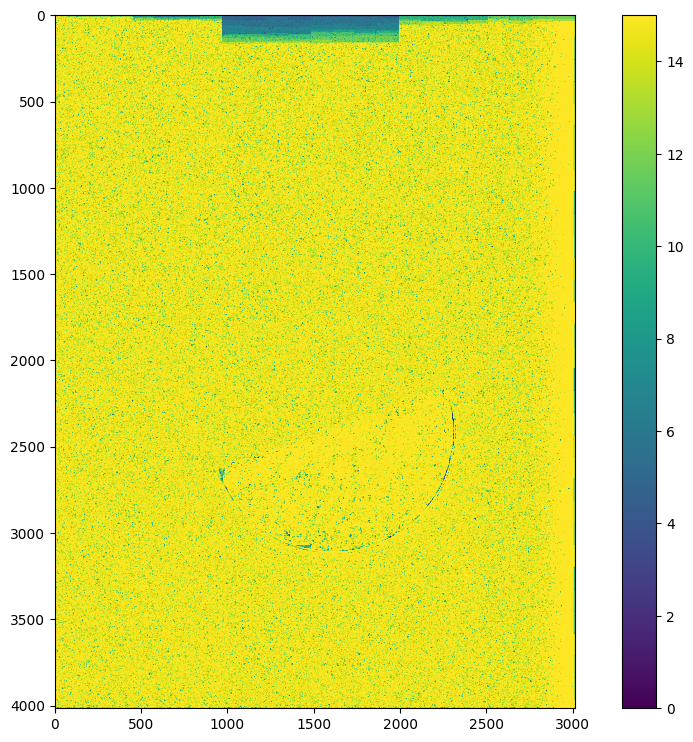

In [86]:
acc_robustness = np.array(debug_dict["accumulated robustness"])
print(acc_robustness.shape)

if debug_dict is not None:
  fig = plt.figure("Accumulated Robustness", figsize=(12,9))
  im = plt.imshow(acc_robustness, interpolation = 'none')
  fig.colorbar(im)
  plt.show()

([], [])

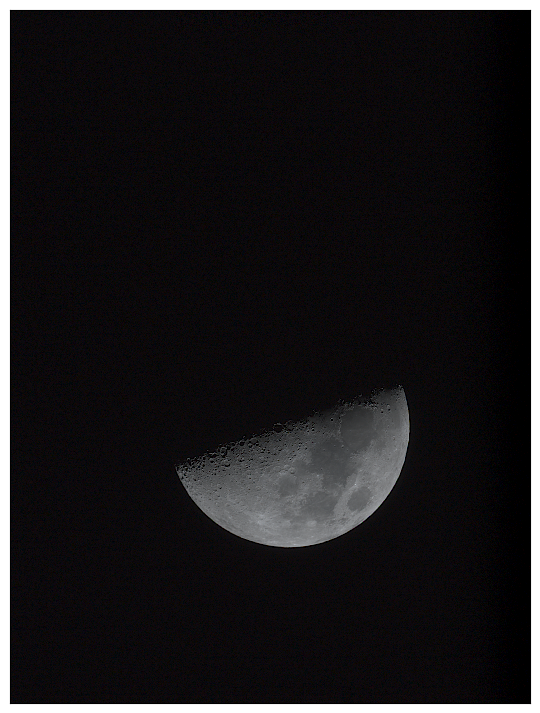

In [87]:
from skimage.util import img_as_ubyte
import numpy as np
from datetime import datetime

# Nettoyer l'image des valeurs 'nan' (les remplacer par 0)
# et s'assurer que les valeurs sont entre 0 et 1
output_clean = np.nan_to_num(output_img, nan=0.0)
output_clean = np.clip(output_clean, 0.0, 1.0)

save_root = os.path.join(pic_root, "super_resolution")
os.makedirs(save_root, exist_ok=True)

plt.imsave(os.path.join(save_root, f"moon_super_resolution_{datetime.now()}.png"), img_as_ubyte(output_clean))
# plotting the result
plt.figure("output", figsize=(12,9))
plt.imshow(output_clean, interpolation = 'none')
plt.xticks([])
plt.yticks([])